<a href="https://colab.research.google.com/github/SORADATA/R--Statistics/blob/main/CreditFraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Première partie: préparation des données **

In [23]:


import kagglehub  # Import de la bibliothèque

# Téléchargement de la dernière version du jeu de données
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Affichage du chemin où les fichiers sont téléchargés
print("Path to dataset files:", path)


import pandas as pd

# Chemin du fichier principal
data_file = f"{path}/creditcard.csv"

# Charger les données dans un DataFrame
data = pd.read_csv(data_file)

# Afficher les premières lignes pour vérifier
print(data.head())



Path to dataset files: /root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  

In [24]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Expliquez pourquoi il est préférable, ici, de normaliser les variables Amount
 et Time. Pourquoi n’est-il pas nécessaire de le faire pour les autres variables?

 Il est préférable de normaliser les variables **`Amount`** et **`Time`** car elles ont des échelles différentes (montants en unités monétaires et temps en secondes ou minutes), ce qui pourrait déséquilibrer les analyses ou les modèles sensibles à la magnitude, comme le PCA ou t-SNE. De plus, ces variables peuvent contenir des valeurs extrêmes qu’il faut rendre moins influentes.

Les autres variables n’ont pas besoin de normalisation, car elles sont déjà sur une échelle comparable (par exemple, des valeurs binaires ou des scores normalisés) et ne présentent pas de disparités significatives.

In [25]:
import numpy as np

import matplotlib.pyplot as plt # Removed extra space before this line
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1,1))
data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1,1))
data.drop(['Time','Amount'], axis=1, inplace=True)

Quel est le risque ici si on tire les échantillons d’entraînement et de test
 aléatoirement? Quelle méthode d’échantillonnage permet d’y remédier?

 **Avec un tirage aléatoire**, le risque est de ne pas respecter la proportion de transactions frauduleuses (0,17%) dans les échantillons, ce qui peut entraîner un déséquilibre entre les classes et nuire à l'apprentissage et à l'évaluation du modèle.

La **stratification** **texte en gras** permet de garantir que cette proportion est respectée dans les échantillons d’entraînement et de test, assurant une représentation équitable des fraudes.

Expliquez pourquoi selon-vous le random undersampling est problématique :

 Le **random undersampling** est problématique car il supprime des données de la classe majoritaire, ce qui peut entraîner :

1. **Perte d’information** importante, réduisant la capacité du modèle à apprendre.
2. **Biais** dans la distribution des données, faussant l'apprentissage.
3. **Réduction de la performance** du modèle sur la classe majoritaire, augmentant les faux positifs.

Il est préférable d'utiliser des méthodes comme le **random oversampling** ou **SMOTE**, qui conservent les informations essentielles tout en équilibrant les classes.

In [38]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Séparation des caractéristiques et des labels
X_o = data.drop('Class', axis=1)
y_o = data['Class']

# Initialisation du StratifiedKFold
sss = StratifiedKFold(n_splits=5)

# Boucle de stratification pour obtenir les indices d'entraînement et de test
for train_index, test_index in sss.split(X_o, y_o):
    # Affichage des indices des jeux d'entraînement et de test
    print("Train:", train_index, "Test:", test_index)

    # Création des échantillons d'entraînement et de test
    original_Xtrain, original_Xtest = X_o.iloc[train_index], X_o.iloc[test_index]
    original_ytrain, original_ytest = y_o.iloc[train_index], y_o.iloc[test_index]

    # Comptage des labels dans l'échantillon d'entraînement
    train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
    # Comptage des labels dans l'échantillon de test
    test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

    print('-' * 100)
    print('Label Distributions: \n')
    print('In training set:')
    print(train_counts_label / len(original_ytrain))
    print('In test set:')
    print(test_counts_label / len(original_ytest))

# Mélange du dataset
data = data.sample(frac=1, random_state=42)

# Séparation des données frauduleuses et non frauduleuses
fraud_df = data.loc[data['Class'] == 1]
non_fraud_df = data.loc[data['Class'] == 0][:492]  # S'assurer d'équilibrer les classes

# Création du DataFrame équilibré
balanced_df = pd.concat([fraud_df, non_fraud_df])

data_rs = balanced_df.sample(frac=1, random_state=42)

# Affichage de l'échantillon équilibré
print(balanced_df['Class'].value_counts())


Train: [ 56961  56962  56963 ... 284804 284805 284806] Test: [    0     1     2 ... 56959 56960 57389]
----------------------------------------------------------------------------------------------------
Label Distributions: 

In training set:
[0.99827514 0.00172486]
In test set:
[0.998262 0.001738]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 56961  56962  56963 ... 115149 115895 115915]
----------------------------------------------------------------------------------------------------
Label Distributions: 

In training set:
[0.99827514 0.00172486]
In test set:
[0.998262 0.001738]
Train: [     0      1      2 ... 284804 284805 284806] Test: [113917 113918 113919 ... 174064 175233 176377]
----------------------------------------------------------------------------------------------------
Label Distributions: 

In training set:
[0.99827076 0.00172924]
In test set:
[0.99827952 0.00172048]
Train: [     0      1      2 ... 284804 284805 284806] Test: [170875 170876 17087

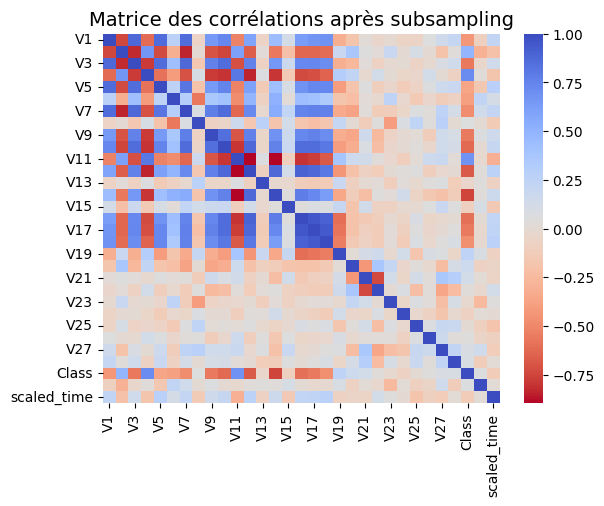

                     V1        V2        V3        V4        V5        V6  \
V1             1.000000 -0.743375  0.880289 -0.617715  0.864352  0.268237   
V2            -0.743375  1.000000 -0.829127  0.661086 -0.733437 -0.312957   
V3             0.880289 -0.829127  1.000000 -0.781399  0.853204  0.424710   
V4            -0.617715  0.661086 -0.781399  1.000000 -0.586365 -0.410891   
V5             0.864352 -0.733437  0.853204 -0.586365  1.000000  0.251945   
V6             0.268237 -0.312957  0.424710 -0.410891  0.251945  1.000000   
V7             0.857225 -0.844686  0.877118 -0.704683  0.814967  0.297924   
V8            -0.073754 -0.006570 -0.167559  0.098686 -0.195488 -0.568386   
V9             0.644766 -0.702491  0.759724 -0.785120  0.642400  0.361446   
V10            0.738455 -0.754231  0.855999 -0.803229  0.752605  0.409270   
V11           -0.525294  0.610579 -0.716013  0.803189 -0.523171 -0.480722   
V12            0.587638 -0.663645  0.756886 -0.838833  0.611408  0.492024   

In [27]:
 sns.heatmap(data_rs.corr(), cmap='coolwarm_r', annot_kws={'size':14})
 plt.title('Matrice des corrélations après subsampling', fontsize=14)
 plt.show()

 # Calcul de la matrice de corrélation de Pearson
correlation_matrix = data_rs.corr(method='pearson')

# Affichage de la matrice sous forme de tableau
print(correlation_matrix)


En étudiant les corrélations entre Class et les autres variables, on remarque que les variables les plus positivement corrélées sont V2, V4, V11 et V19 et que les variables les plus négativement corrélées sont V10, V12, V14 et V17. Pour étudier la présence d’éventuels outliers, on représente les boxplots de ces variables en fonction de la classe des observations.

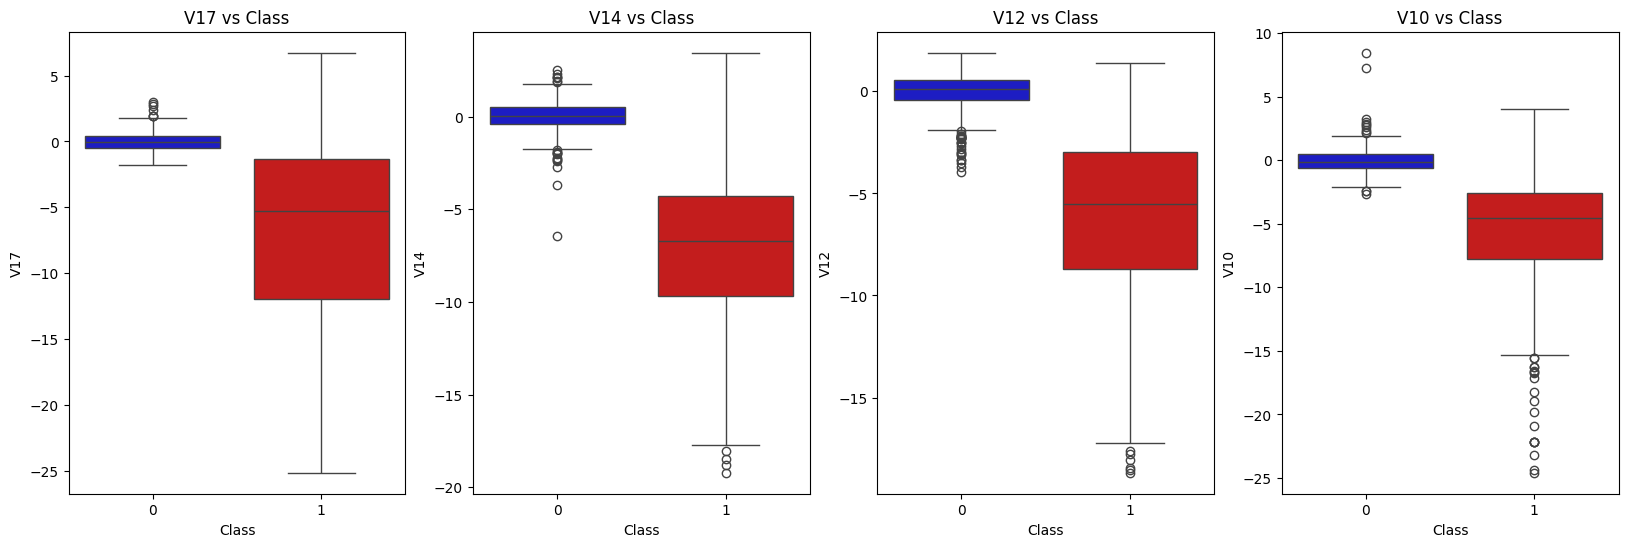

In [28]:
f, axes = plt.subplots(ncols=4, figsize=(20,6))

colors = ["#0101DF", "#DF0101"] # Remove the extra spaces from the beginning of this line.
sns.boxplot(x="Class", y="V17", data=data_rs, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class')
sns.boxplot(x="Class", y="V14", data=data_rs, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class')
sns.boxplot(x="Class", y="V12", data=data_rs, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class')
sns.boxplot(x="Class", y="V10", data=data_rs, palette=colors, ax=axes[3])

axes[3].set_title('V10 vs Class')
plt.show()

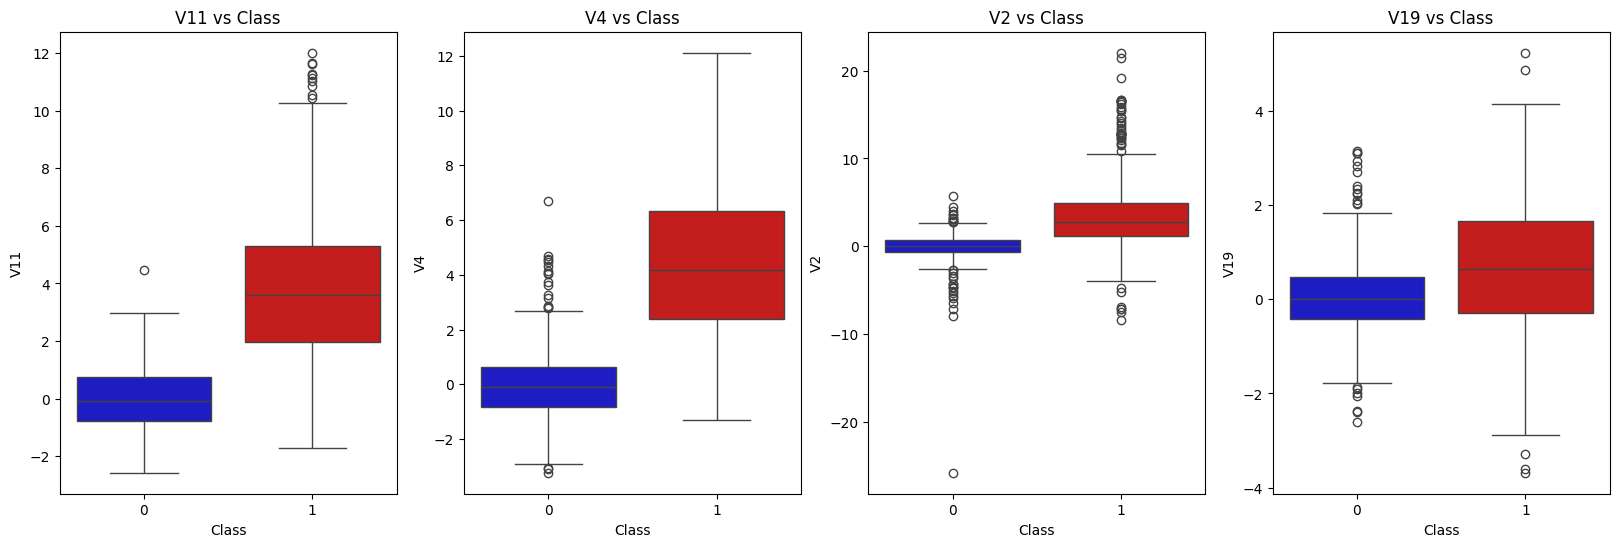

In [29]:
 f, axes = plt.subplots(ncols=4, figsize=(20,6))
 sns.boxplot(x="Class", y="V11", data=data_rs, palette=colors, ax=axes[0])
 axes[0].set_title('V11 vs Class')
 sns.boxplot(x="Class", y="V4", data=data_rs, palette=colors, ax=axes[1])
 axes[1].set_title('V4 vs Class')
 sns.boxplot(x="Class", y="V2", data=data_rs, palette=colors, ax=axes[2])
 axes[2].set_title('V2 vs Class')
 sns.boxplot(x="Class", y="V19", data=data_rs, palette=colors, ax=axes[3])
 axes[3].set_title('V19 vs Class')

 plt.show()

Vous semble-t-il y avoir des outliers? S’il y en avait, expliquez pourquoi il
 peut ne pas être judicieux de les retirer de la base de données : Oui il existe des valeurs abérantes dans la base de données Les outliers (valeurs aberrantes) peuvent être importantes dans des contextes comme la détection de la fraude, car ils peuvent représenter des comportements rares mais significatifs, comme des transactions frauduleuses. Bien que la normalisation ou la réduction des données puisse atténuer leur impact, il n'est pas toujours judicieux de les retirer, car cela pourrait faire perdre des informations essentielles pour le modèle. Les modèles de machine learning robustes, comme les forêts aléatoires, peuvent gérer les outliers sans que leur présence n'affecte négativement la performance. En résumé, plutôt que de retirer les outliers, il est souvent préférable de les conserver, surtout lorsqu'ils apportent des informations pertinentes.


## Partie 2: Apprentissage non-supervisé

 Pour explorer un peu mieux les données, on se propose de les représenter dans un sous-espace de
 dimension réduite. Pour cela, on utilise deux méthodes différentes: l’ACP et le t-SNE, puis on
 visualise les classes sur les axes obtenus.
 On commence par scinder la base de données data_rs en deux bases, une base y contenant la
 variable Class qu’on cherchera à prédire, et une base X contenant les autres variables. Ensuite, on
 calcule l’ACP de la base X. On affiche ensuite les sorties habituelles.

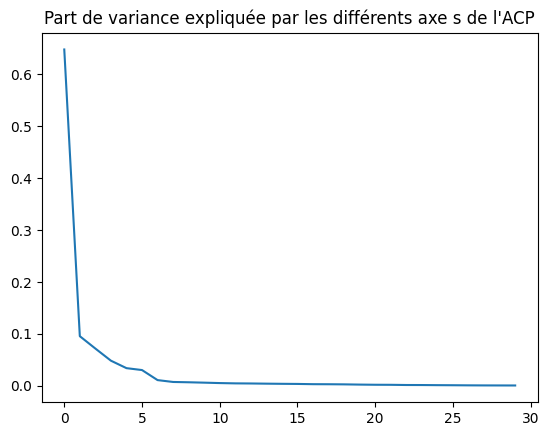

In [32]:
 from sklearn.decomposition import PCA
 X = data_rs.drop('Class', axis=1)
 y = data_rs['Class']
 pca=PCA()
 pca.fit(X)
 plt.plot(pca.explained_variance_ratio_)
 plt.title("Part de variance expliquée par les différents axe s de l'ACP")



plt.show()

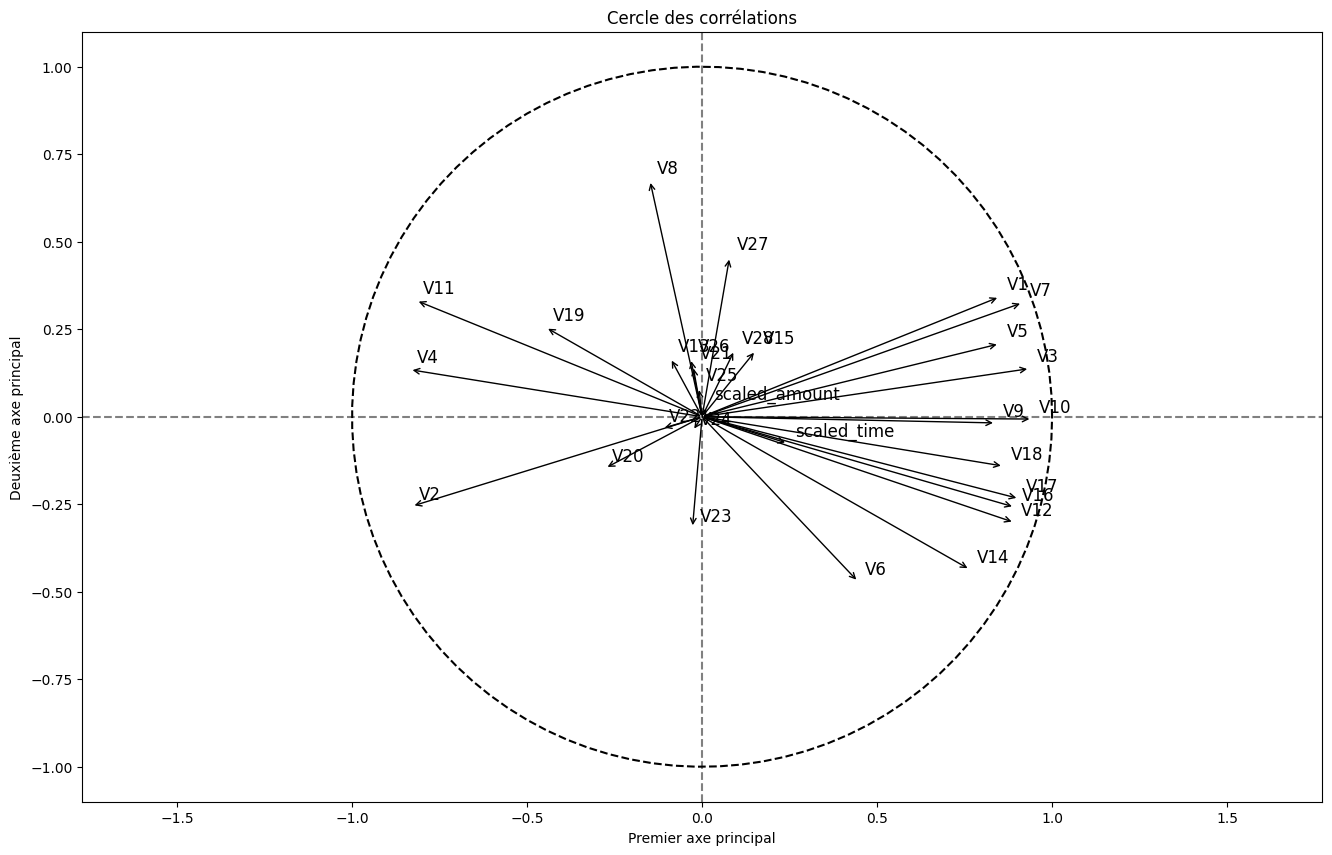

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_correlation_circle(axe1, axe2, data, label1, label2):
    fig, ax = plt.subplots(figsize=(16, 10))

    for i in range(data.shape[1]):
        x = np.corrcoef(axe1, data[data.columns[i]])[0, 1]
        y = np.corrcoef(axe2, data[data.columns[i]])[0, 1]
        ax.annotate("", xy=(x, y), xytext=(0, 0), arrowprops=dict(arrowstyle="->"))
        ax.annotate(data.columns[i], (x + 0.02, y + 0.02), size=12)

    ax.set_title('Cercle des corrélations')
    ax.axhline(y=0, color="grey", linestyle="--")
    ax.axvline(x=0, color="grey", linestyle="--")

    # Cercle unitaire
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an), linestyle="--", color="black")

    plt.axis('equal')
    plt.xlabel(str(label1))
    plt.ylabel(str(label2))
    plt.show()

# Exemple d'application avec PCA
X_pca = PCA(n_components=2).fit_transform(X)  # X est la matrice de données
plot_correlation_circle(X_pca[:, 0], X_pca[:, 1], X, "Premier axe principal", "Deuxième axe principal")


 Interprétez les résultats de l’ACP: combien d’axes sont à garder? Comment
 les variables les plus corrélées à Class contribuent aux deux premiers axes?

 On garde 2 axes principales qui expliquent la majeure partie de la variance selon la méthode de coude :

Nombre d'axes principaux : On conserve les deux premiers axes principaux qui expliquent ensemble 75 % de la variance cumulée.

Axe 1 : Il oppose des variables comme V2 et V20 (associées à une certaine dimension) à V23 et V6 (associées à une autre dimension). V23 contribue particulièrement à cet axe en raison de sa forte corrélation positive avec l'axe (flèche longue et proche du cercle).

Axe 2 : Il oppose des variables comme V1, V5, et V3 à V14, V18, et V12. Parmi elles, V3 et V16 sont particulièrement bien corrélées à cet axe.












 Méthode t-SNE

 Pour évaluer les résultats de l’ACP, on les compare à ceux produits par une autre méthode, le
 t-SNE. On représente ensuite les données séparées par classe en deux dimensions à l’aide des deux
 méthodes.

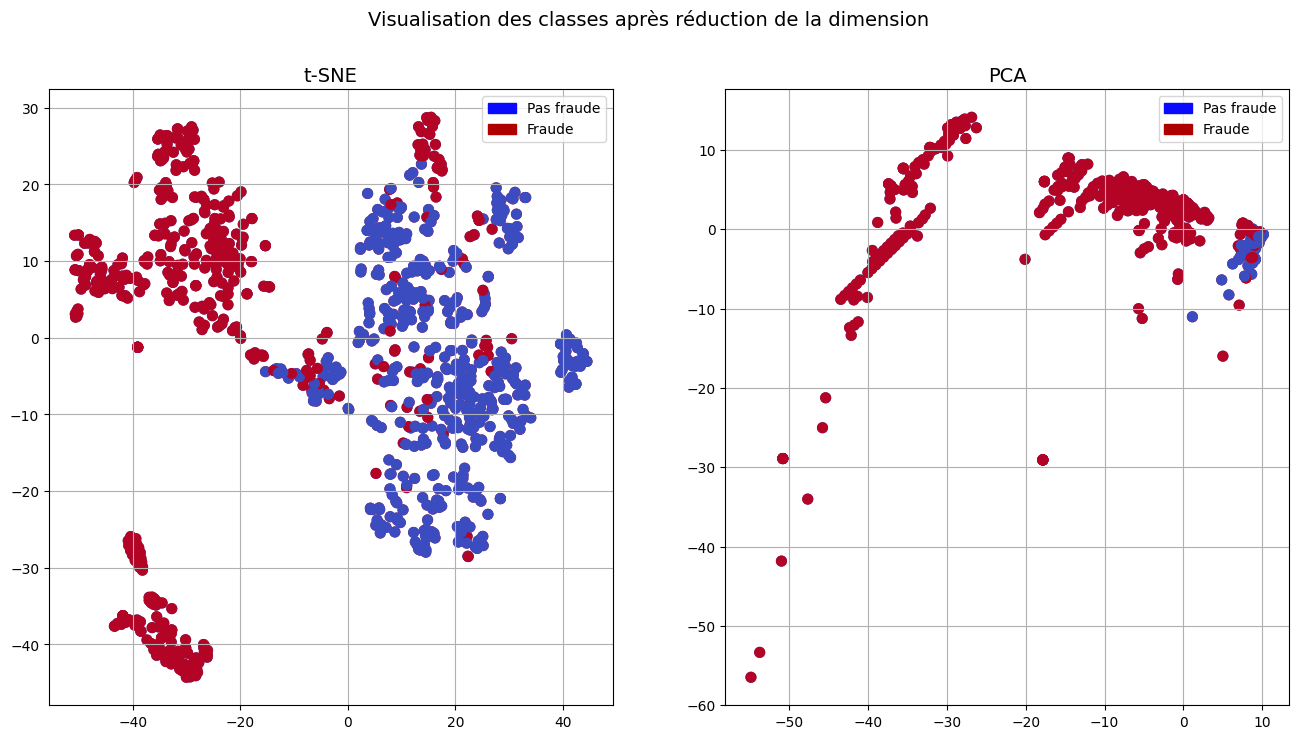

In [34]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Supposons que X, y, et X_pca soient déjà définis

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
f.suptitle('Visualisation des classes après réduction de la dimension', fontsize=14)

blue_patch = mpatches.Patch(color='#0A0AFF', label='Pas fraude')
red_patch = mpatches.Patch(color='#AF0000', label='Fraude')

ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])

ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=(y == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

plt.show()


 Qu’indique le fait que les deux classes apparaissent nettement plus séparées
 dans les résultats du t-SNE que dans ceux de l’ACP?

 Le t-SNE montre une meilleure séparation des classes que l’ACP car il capture les **relations complexes non linéaires** dans les données, tandis que l’ACP, étant une méthode linéaire, ne révèle que les structures globales basées sur la variance. Le t-SNE met l'accent sur les **distances locales**, ce qui le rend plus adapté à la visualisation et à la séparation des clusters.

# **Partie 3: prédiction de la fraude**

On se propose maintenant de constuire un modèle permettant de détecter les transactions frauduleuses. Etant donné qu'il s'agit d'estimer une variable binaire, on utilise la régression logistique.

On rappelle que la vraisemblance conditionnelle L(Y/X,Beta) d'un modèle de régression logistique donnée par :
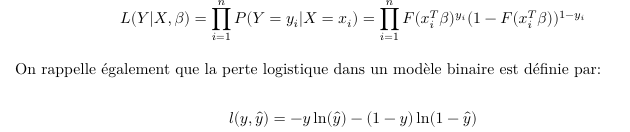

Justifiez que l’estimation d’une régression logistique par maximum de
 vraisemblance est équivalente à la minimisation du risque empirique pour la perte logistique.

L'estimation d'une régression logistique par maximum de vraisemblance est équivalente à la minimisation du risque empirique pour la perte logistique.

Maximum de vraisemblance : On cherche à maximiser la fonction de vraisemblance, qui mesure la probabilité d'observer les données réelles sous le modèle logistique. La log-vraisemblance est une somme de termes liés à la probabilité des observations
𝑦
𝑖
y
i
​
  données
𝑥
𝑖
x
i
​
 .

Risque empirique et perte logistique : La perte logistique est une fonction qui mesure l'erreur entre les prédictions du modèle et les valeurs réelles. Le risque empirique est la moyenne de cette perte sur toutes les observations.

Équivalence : Maximiser la log-vraisemblance revient à minimiser le risque empirique, car les deux fonctions sont opposées par leur signe. Ainsi, les deux approches mènent à la même solution pour les paramètres du modèle.

In [40]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split # Added import for train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

logreg = sm.Logit(y_train,X_train).fit()
logreg.summary()

Optimization terminated successfully.
         Current function value: 0.106555
         Iterations 22


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Class   No. Observations:                  738
Model:                          Logit   Df Residuals:                      708
Method:                           MLE   Df Model:                           29
Date:                Wed, 04 Dec 2024   Pseudo R-squ.:                  0.8463
Time:                        17:35:52   Log-Likelihood:                -78.637
converged:                       True   LL-Null:                       -511.54
Covariance Type:            nonrobust   LLR p-value:                1.715e-163
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
V1              -10.7766      1.685     -6.396      0.000     -14.079      -7.474
V2               11.8478      2.469      4.799      0.000       7.009      16.687
V3              -27.7148      4.864     -5.698      0.000     -37.248     -18.182
V4               18.2255      3.316      5.497      0.000      11.727      24.724
V5              -18.4774      3.245     -5.695      0.000     -24.837     -12.118
V6               -6.7134      1.360     -4.937      0.000      -9.378      -4.048
V7              -37.1626      7.121     -5.219      0.000     -51.119     -23.207
V8                6.8357      1.397      4.893      0.000       4.097       9.574
V9              -19.6584      3.787     -5.191      0.000     -27.080     -12.237
V10             -44.9909      8.594     -5.235      0.000     -61.834     -28.148
V11              30.3557      5.755      5.274      0.000      19.075      41.636
V12             -55.1227     10.374     -5.313      0.000     -75.456     -34.790
V13               0.2974      0.235      1.264      0.206      -0.164       0.759
V14             -57.6335     10.750     -5.361      0.000     -78.702     -36.565
V15              -1.5757      0.358     -4.406      0.000      -2.277      -0.875
V16             -51.7566      9.686     -5.344      0.000     -70.740     -32.773
V17             -93.0374     17.561     -5.298      0.000    -127.456     -58.619
V18             -34.5901      6.529     -5.298      0.000     -47.388     -21.793
V19              11.9542      2.364      5.057      0.000       7.321      16.588
V20               4.7237      0.845      5.593      0.000       3.068       6.379
V21               7.3059      1.510      4.838      0.000       4.346      10.266
V22               1.7067      0.496      3.442      0.001       0.735       2.679
V23               0.1445      0.708      0.204      0.838      -1.243       1.532
V24              -0.5412      0.465     -1.165      0.244      -1.452       0.370
V25               0.6284      0.646      0.972      0.331      -0.638       1.895
V26               0.0639      0.602      0.106      0.915      -1.117       1.245
V27               8.7059      1.790      4.862      0.000       5.197      12.215
V28               7.7213      2.217      3.483      0.000       3.376      12.067
scaled_amount     0.5373      0.540      0.996      0.319      -0.521       1.595
scaled_time      -1.5598      0.695     -2.244      0.025      -2.922      -0.198
=================================================================================

Possibly complete quasi-separation: A fraction 0.47 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Pourtesterl’efficacitédumodèle,oncalculesesprédictionssurlesdonnéesdetestenattribuantà chaqueobservationlaclassejugéelaplusprobableparlemodèle.Ondétermineensuitelamatrice
 deconfusion.

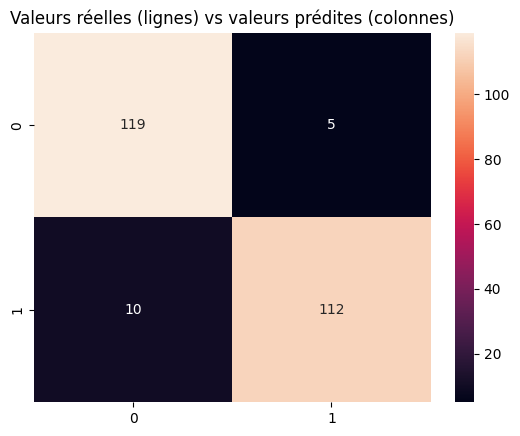

Accuracy: 0.9390243902439024
Precision: 0.9572649572649573
Recall: 0.9180327868852459
F1-score: 0.9372384937238494


In [43]:
# Importer les métriques nécessaires depuis sklearn
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions des probabilités
y_prob = logreg.predict(X_test)

# Arrondir les probabilités pour obtenir les classes prédites (0 ou 1)
y_pred = list(map(round, y_prob))

# Calcul de la matrice de confusion
conf = confusion_matrix(y_test, y_pred)

# Affichage de la matrice de confusion
sns.heatmap(conf, annot=True, fmt=".0f")
plt.title("Valeurs réelles (lignes) vs valeurs prédites (colonnes)")
plt.show()

# Calcul des différentes métriques
print("Accuracy: " + str(accuracy_score(y_test, y_pred)))
print("Precision: " + str(precision_score(y_test, y_pred)))
print("Recall: " + str(recall_score(y_test, y_pred)))
print("F1-score: " + str(f1_score(y_test, y_pred)))


La courbe ROC

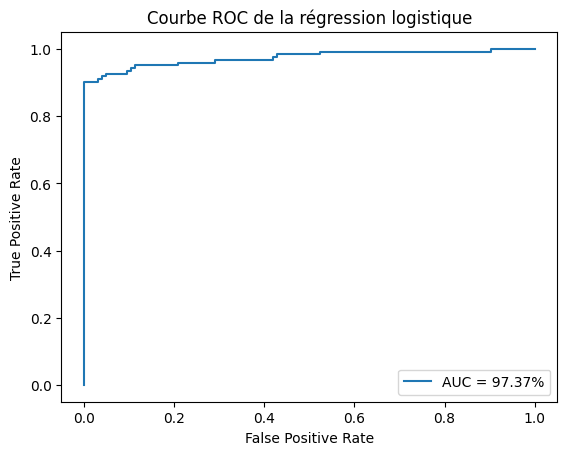

In [45]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Entraînement du modèle de régression logistique
logit = LogisticRegression().fit(X_train, y_train)

# Prédiction des probabilités pour la classe 1 (fraude)
y_prob = logit.predict_proba(X_test)[:, 1]

# Calcul des valeurs FPR (False Positive Rate) et TPR (True Positive Rate)
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Calcul de l'AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc * 100, 2)) + "%")

# Ajouter des labels et un titre
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('Courbe ROC de la régression logistique')

# Afficher la légende
plt.legend(loc=4)

# Afficher le graphique
plt.show()


Interprétation : Le modèle semble effectivement efficace pour détecter la fraude, car l'AUC est élevée (97,37%) et la courbe ROC montre un bon compromis entre les taux de vrais positifs et de faux positifs. Cela indique que le modèle a une excellente capacité à distinguer entre les transactions frauduleuses et non frauduleuses.

Modèle pénalisé **

Afin d’étudier plus précisément les performances du modèle, on se propose d’en estimer une version
 pénalisée. Pour cela, on utilise une gridsearch par validation croisée en testant un ensemble de
 niveaux de pénalités et plusieurs formes de pénalisation. Le paramètre C correspond à l’inverse
 mathématique du niveau de pénalité. On rappelle que la norme l_1 correspond à la norme absolue
 et que la norme l_2 correspond à la norme euclidienne.

In [46]:
 from sklearn.model_selection import GridSearchCV

 grid_params = {"penalty": ['l1', 'l2'], 'C': np.arange(0,1,0.1)}

 grid_log_reg = GridSearchCV(LogisticRegression(), grid_params)
 grid_log_reg.fit(X_train, y_train)
 log_pen = grid_log_reg.best_estimator_

 print(grid_log_reg.best_params_)

{'C': 0.30000000000000004, 'penalty': 'l2'}
